<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Segmentación por clustering. Caso EM</h2>

### Mixtura de Gausianas - Expectación Maximización (EM)
#### Author: Pedro Latorre Carmona
#### Curso: 2024-2025

Versión 1.0

---

En esta práctica, la idea es aplicar el algoritmo de agrupamiento de EM sobre una imagen en color de la que no se sabe a priori el número de grupos que tiene.

Los objetivos a cubrir en esta práctica son:

1. Utilizar el "Bayes Information Criterion" (BIC) para determinar el número ideal de grupos (Gausianas) en la imagen. Enlaces de utilidad:

    https://en.wikipedia.org/wiki/Bayesian_information_criterion

    https://scikit-learn.org/dev/auto_examples/mixture/plot_gmm_selection.html


2. Analizar el efecto de los diferentes parámetros de la mixtura de Gausianas en el resultado visual de segmentación de la imagen en color.

Los elementos a analizar son:

- El valor del umbral de parada
- El número de iteraciones
- La forma de las matrices de covarianza


### Mixtura de Gausianas (Mixture of Gaussians, o MoGs)

El algoritmo de mixtura de Gausianas intenta resolver e inferir cuáles son las características, número y peso de un conjunto de Gausianas, en un espacio $D-$dimensional que permitirían modelizar una determinada distribución de datos.

Supongamos un **vector de características** que representa un dato que queremos clasificar. La distribución de probabilidad de ese vector de características a lo largo del espacio que lo define se puede poner como:

$p(\mathbf{x}) = \sum_{j=1}^{m} p(\Omega_{j})\cdot p(\mathbf{x}|\Omega_{j})$

Una función Gausiana en un espacio $D-$dimensional puede escribirse de la siguiente forma:

$p(\mathbf{x}|\Omega_{j})=\frac{1}{(2\pi)^{\frac{d}{2}}|\Sigma_{j}|^{\frac{1}{2}}}\exp\left(-\frac{1}{2}([\mathbf{x}-\mathbf{\mu}_{j}]^{T}\Sigma_{j}^{-1}[\mathbf{x}-\mathbf{\mu}_{j}])\right)$

donde:

1. $\mathbf{\mu}_{j}$ es el vector que representa las coordenadas del **centroide** j-ésimo
2. $\Sigma_{j}$ es la matriz de covarianza asociada al *clúster* j-ésimo

## ¿Qué resuelve el algoritmo de mixtura de Gausianas?

Lo que indica es el grupo al que pertenece un vector, $\mathbf{x}$, porque busca:

$j\equiv\max_{j\in\Omega_{i}} \left\{p(\Omega_{j}|\mathbf{x})\right\}$

## Método de resolución

Normalmente, el método que se usa para resolver este problema de optimización es el denominado de **expectación**-**maximización** (**EM**). Consta de dos partes:

1. Paso **E** (Expectación):

<img src="pics/PasoE.png">

2. Paso **M** (Maximización):

<img src="pics/PasoM.png">

In [5]:
%matplotlib inline
%pip install scikit-image
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\urban\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\urban\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.2/11.1 MB 5.9 MB/s eta 0:00:02
   -- ------------------------------------- 0.7/11.1 MB 9.1 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/11.1 MB 10.4 MB/s eta 0:00:01
   ------- -------------------------------- 2.1/11.1 MB 12.3 MB/s eta 0:00:01
   ---------- ----------------------------- 3.0/11.1 MB 13.7 MB/s eta 0:00:01
   -------------- ------------------------- 4.1/11.1 MB 15.5 MB/s eta 0:00:01
   ------------------- -------------------- 5.4/11.1 MB 17.2 MB/s eta 0:00:01
   ------------------------ --------------- 6.9/11.1 MB 19.3 MB/s eta 0:00:01
   ------------------------------ --------- 8.5/11.1 MB 20.9 MB/s eta 0:00:01
   ----------------------------------- ---- 9.9/11.1 MB 22.5 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.1 MB 20.7 MB/s eta 0:00:01
   ---------------------------------------  11.1/11.1 MB 22.6 MB/s eta 0

In [6]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skimage import io

1. Preparación del entorno y carga de la imagen

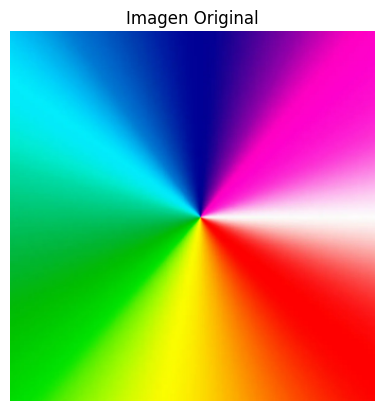

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from skimage import io

# Cargar la imagen en color
imagen = io.imread('./RGBImage.png')  # Reemplaza con la ruta de tu imagen

# Mostrar la imagen original
plt.imshow(imagen)
plt.title('Imagen Original')
plt.axis('off')
plt.show()


2. Preprocesamiento: convertir la imagen en un conjunto de datos adecuado para EM

In [8]:
# Obtener las dimensiones de la imagen
alto, ancho, canales = imagen.shape

# Reorganizar la imagen en una matriz de forma (n_muestras, n_características)
X = imagen.reshape(-1, canales)  # Cada fila es un píxel con 3 características: R, G, B


3. Determinación del número ideal de grupos usando BIC
El BIC (Bayes Information Criterion) nos ayuda a seleccionar el número óptimo de componentes en el modelo de mezcla gaussiana. Se prueba con distintos valores de G (número de clusters) y se elige aquel con el menor BIC.

python
Copiar código


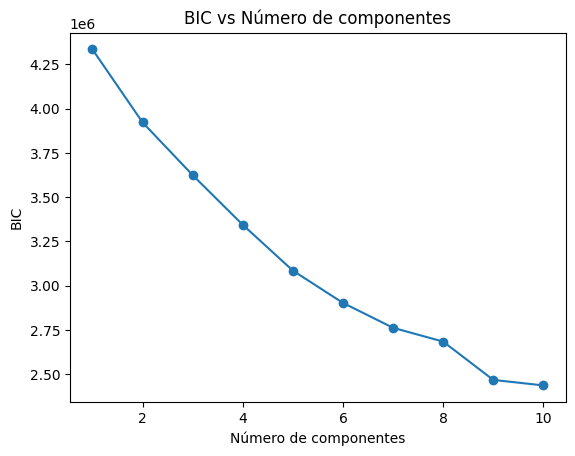

El número óptimo de clusters según BIC es: 10


In [9]:
# Rango de valores para el número de clusters a probar
componentes = range(1, 11)

bic_scores = []

for n in componentes:
    # Crear y ajustar el modelo para cada número de componentes
    modelo = GaussianMixture(n_components=n, covariance_type='full', random_state=0)
    modelo.fit(X)
    bic_scores.append(modelo.bic(X))

# Graficar el BIC para cada número de componentes
plt.plot(componentes, bic_scores, marker='o')
plt.title('BIC vs Número de componentes')
plt.xlabel('Número de componentes')
plt.ylabel('BIC')
plt.show()

# Seleccionar el número óptimo de clusters basado en el mínimo BIC
optimal_n = componentes[np.argmin(bic_scores)]
print(f'El número óptimo de clusters según BIC es: {optimal_n}')


4. Aplicar EM con el número óptimo de clusters y visualizar la segmentación

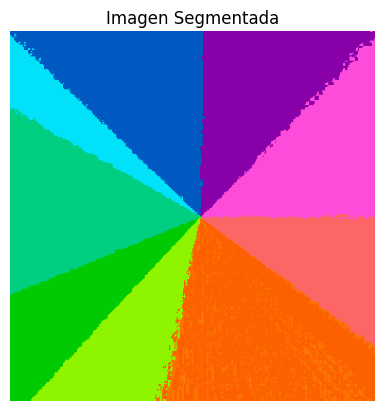

In [10]:
# Crear y entrenar el modelo con el número óptimo de clusters
modelo_optimo = GaussianMixture(n_components=optimal_n, covariance_type='full', 
                                tol=1e-3, max_iter=100, random_state=0)
modelo_optimo.fit(X)

# Predecir las etiquetas (clusters) para cada píxel
etiquetas = modelo_optimo.predict(X)

# Reconstruir la imagen segmentada, asignando a cada píxel el color promedio de su cluster
colores_cluster = np.dot(np.eye(optimal_n)[etiquetas], modelo_optimo.means_)
imagen_segmentada = colores_cluster.reshape(alto, ancho, canales).astype(np.uint8)

plt.imshow(imagen_segmentada)
plt.title('Imagen Segmentada')
plt.axis('off')
plt.show()


5. Análisis del efecto de los diferentes parámetros

a) Variando el umbral de parada (tol) y el número de iteraciones (max_iter)
Puedes experimentar cambiando los parámetros tol y max_iter en el modelo. Por ejemplo:

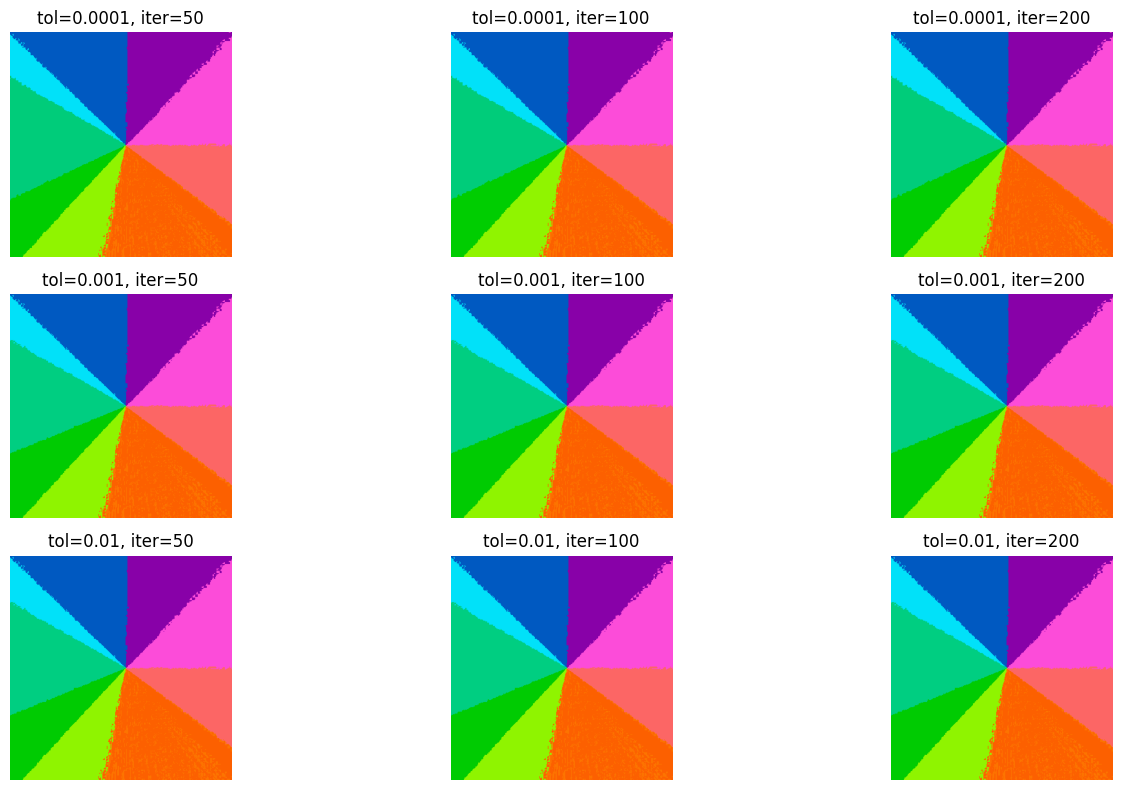

In [11]:
# Probar diferentes valores de umbral de parada y número de iteraciones
tolerancias = [1e-4, 1e-3, 1e-2]
iteraciones = [50, 100, 200]

resultados = {}

for tol in tolerancias:
    for max_iter in iteraciones:
        modelo = GaussianMixture(n_components=optimal_n, covariance_type='full', 
                                tol=tol, max_iter=max_iter, random_state=0)
        modelo.fit(X)
        etiquetas = modelo.predict(X)
        colores_cluster = np.dot(np.eye(optimal_n)[etiquetas], modelo.means_)
        imagen_seg = colores_cluster.reshape(alto, ancho, canales).astype(np.uint8)
        resultados[(tol, max_iter)] = imagen_seg

# Visualizar resultados para diferentes combinaciones
fig, axs = plt.subplots(len(tolerancias), len(iteraciones), figsize=(15, 8))
for i, tol in enumerate(tolerancias):
    for j, max_iter in enumerate(iteraciones):
        axs[i, j].imshow(resultados[(tol, max_iter)])
        axs[i, j].set_title(f'tol={tol}, iter={max_iter}')
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()


b) Variando la forma de las matrices de covarianza
El parámetro covariance_type puede tomar diferentes valores, lo que afecta la forma de las matrices de covarianza:

'full': matrices generales (cada cluster tiene su propia matriz de covarianza completa).
'tied': una única matriz de covarianza compartida entre todos los clusters.
'diag': matrices diagonalizadas (cada cluster tiene su propia matriz diagonal).
'spherical': cada cluster tiene su propia varianza esférica (un solo valor).
python
Copiar código


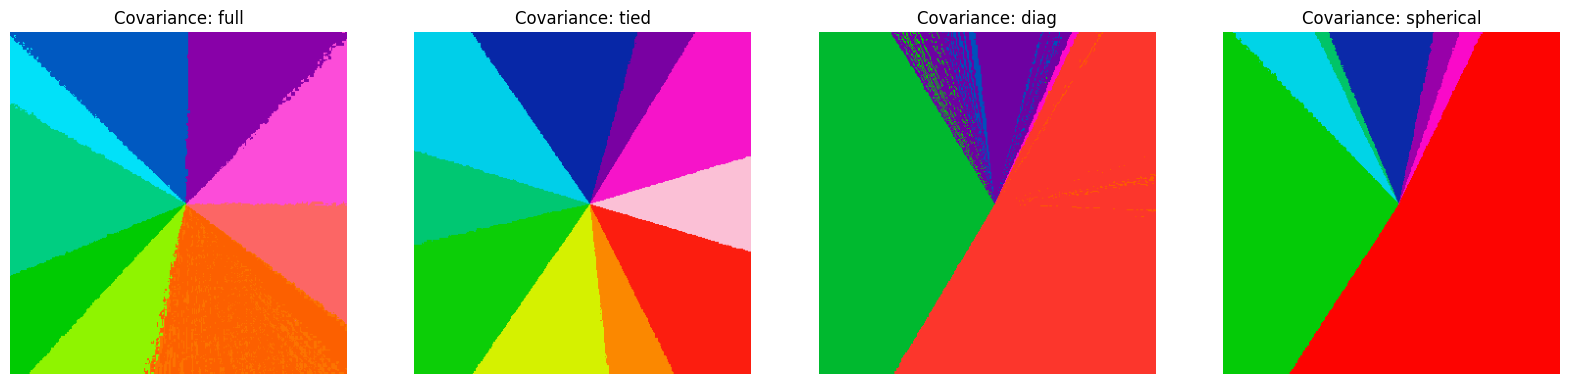

In [12]:
formas_cov = ['full', 'tied', 'diag', 'spherical']
resultados_cov = {}

for cov_type in formas_cov:
    modelo = GaussianMixture(n_components=optimal_n, covariance_type=cov_type, 
                            tol=1e-3, max_iter=100, random_state=0)
    modelo.fit(X)
    etiquetas = modelo.predict(X)
    colores_cluster = np.dot(np.eye(optimal_n)[etiquetas], modelo.means_)
    imagen_seg = colores_cluster.reshape(alto, ancho, canales).astype(np.uint8)
    resultados_cov[cov_type] = imagen_seg

# Visualizar resultados para diferentes formas de covarianza
fig, axs = plt.subplots(1, len(formas_cov), figsize=(20, 5))
for i, cov_type in enumerate(formas_cov):
    axs[i].imshow(resultados_cov[cov_type])
    axs[i].set_title(f'Covariance: {cov_type}')
    axs[i].axis('off')
plt.show()


# PRUEBA 01

#  1. Importar librerías

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

## 2. Cargar la imagen
Sugerencia: puedes probar con cualquier imagen en color. 
En este ejemplo se usa una imagen de ejemplo en internet o local.


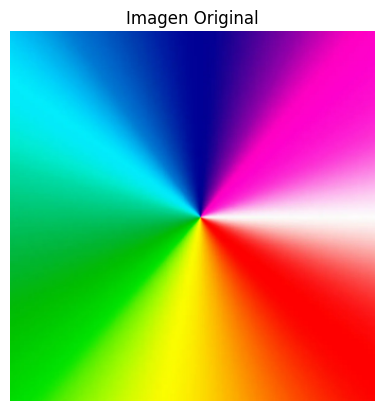

In [28]:
# Cargar la imagen en color
imagen = io.imread('./RGBImage.png')  # Reemplaza con la ruta de tu imagen
img = imagen.astype(np.float64) / 255.0

# Mostrar la imagen original
plt.imshow(imagen)
plt.title('Imagen Original')
plt.axis('off')
plt.show()

 ## 3. Transformar la imagen en un arreglo 2D de datos de color
 Tomamos cada pixel en R, G, B y lo interpretamos como un punto en el espacio (R,G,B)

In [29]:
rows, cols, ch = img.shape
img_2d = img.reshape(rows*cols, ch)  # (N_pixels, 3)

 ## 4. Determinar el número de componentes GMM usando BIC

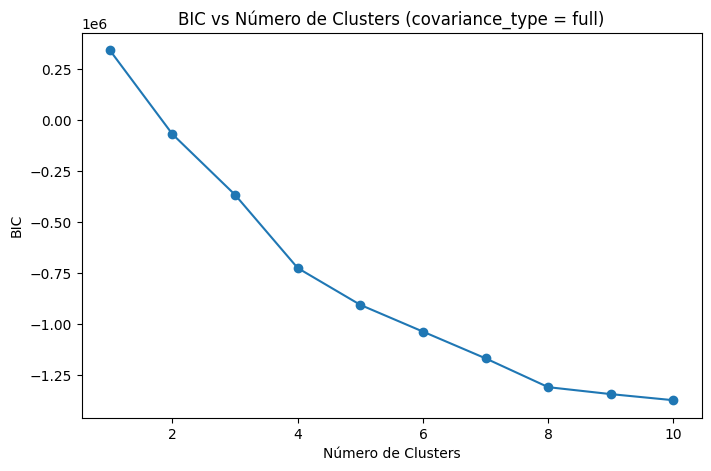

Mejor número de clusters según BIC: 10


In [30]:
def calcular_BIC(data, max_clusters=10, cov_type='full', 
                 max_iter=100, tol=1e-3, random_state=42):
    """
    Calcula el criterio BIC para distintos números de clusters (1..max_clusters)
    Devuelve:
      - lista con número de clusters
      - lista con el BIC obtenido para cada n_clusters
    """
    n_clusters_range = range(1, max_clusters+1)
    bics = []

    for n in n_clusters_range:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type=cov_type,
            max_iter=max_iter,
            tol=tol,
            random_state=random_state
        )
        gmm.fit(data)
        bics.append(gmm.bic(data))

    return list(n_clusters_range), bics

# Probar con distintos números de clusters
max_clusters = 10
cov_type = 'full'  # 'full', 'tied', 'diag', 'spherical'
max_iter = 100
tol = 1e-3

n_clusters_range, bics = calcular_BIC(img_2d, max_clusters=max_clusters, 
                                      cov_type=cov_type, 
                                      max_iter=max_iter, tol=tol)

# Graficar el BIC en función del número de clusters
plt.figure(figsize=(8,5))
plt.plot(n_clusters_range, bics, marker='o')
plt.title('BIC vs Número de Clusters (covariance_type = {})'.format(cov_type))
plt.xlabel('Número de Clusters')
plt.ylabel('BIC')
plt.show()

# Elegir el número de clusters que minimice el BIC
best_n_clusters = n_clusters_range[np.argmin(bics)]
print("Mejor número de clusters según BIC:", best_n_clusters)

## 5. Ajustar el GMM con el número óptimo de componentes

In [31]:
gmm_best = GaussianMixture(
    n_components=best_n_clusters,
    covariance_type=cov_type,
    max_iter=max_iter,
    tol=tol,
    random_state=42
)
gmm_best.fit(img_2d)

# Predecir la etiqueta (cluster) de cada píxel
labels = gmm_best.predict(img_2d)
labels_2d = labels.reshape(rows, cols)

 ## 6. Visualizar la segmentación resultante
Opcional: reconstruir usando los centros (medias) de cada clúster

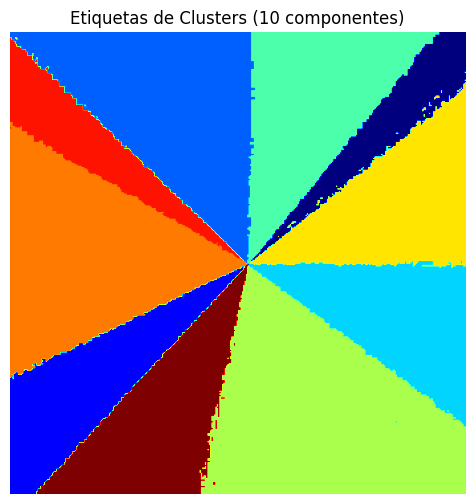

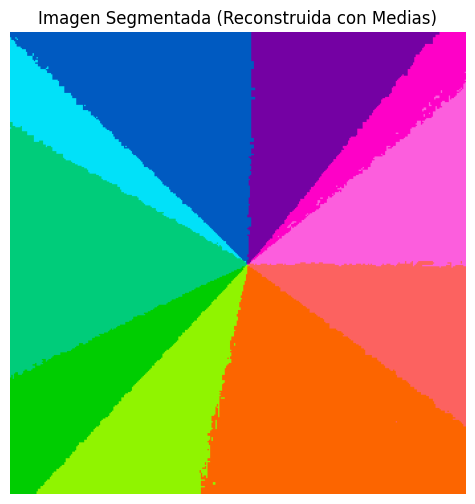

In [32]:
segmented_img = gmm_best.means_[labels]

segmented_img_2d = segmented_img.reshape(rows, cols, ch)

# Mostrar la imagen segmentada con la paleta "jet" para ver las regiones
plt.figure(figsize=(6,6))
plt.imshow(labels_2d, cmap='jet')
plt.title("Etiquetas de Clusters ({} componentes)".format(best_n_clusters))
plt.axis("off")
plt.show()

# Mostrar la imagen segmentada reconstruida
plt.figure(figsize=(6,6))
plt.imshow(segmented_img_2d)
plt.title("Imagen Segmentada (Reconstruida con Medias)")
plt.axis("off")
plt.show()

 ## 7. Análisis de parámetros
 Para analizar la influencia de distintos parámetros, 
 podemos encapsular el proceso en una función y variar.


In [33]:
def segmentar_imagen(data, n_clusters, cov_type='full', 
                     max_iter=100, tol=1e-3, random_state=42):
    """
    Ajusta un GMM a la imagen (data en 2D) y devuelve:
    - Etiquetas (labels) del cluster para cada pixel
    - Imagen segmentada reconstruida
    """
    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type=cov_type,
        max_iter=max_iter,
        tol=tol,
        random_state=random_state
    )
    gmm.fit(data)
    labels = gmm.predict(data)
    segmented_data = gmm.means_[labels]
    return labels, segmented_data


### 7.1 Efecto del número de iteraciones

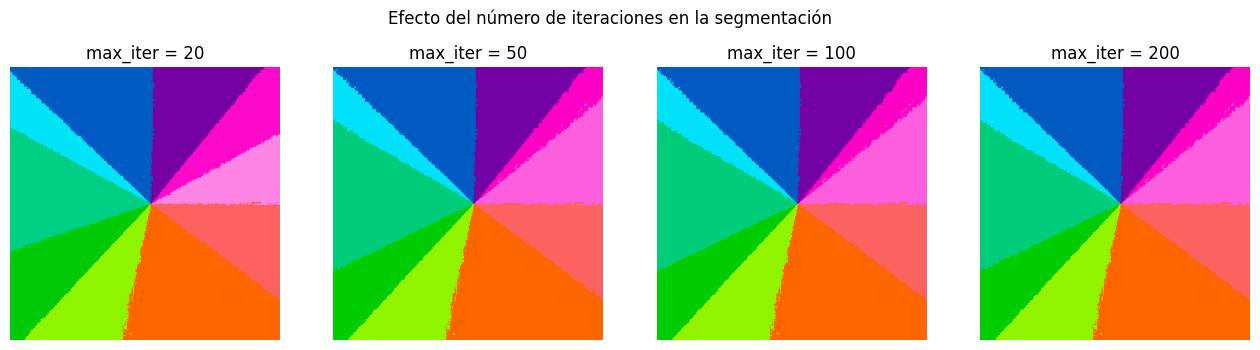

In [34]:
max_iters_list = [20, 50, 100, 200]
fig, axes = plt.subplots(1, len(max_iters_list), figsize=(16,4))
for i, max_iters in enumerate(max_iters_list):
    labels_i, seg_i = segmentar_imagen(img_2d, best_n_clusters, 
                                       cov_type='full', 
                                       max_iter=max_iters, tol=tol)
    seg_i_2d = seg_i.reshape(rows, cols, ch)
    axes[i].imshow(seg_i_2d)
    axes[i].set_title(f'max_iter = {max_iters}')
    axes[i].axis('off')

plt.suptitle("Efecto del número de iteraciones en la segmentación")
plt.show()


### 7.2 Efecto del umbral de convergencia (tol)

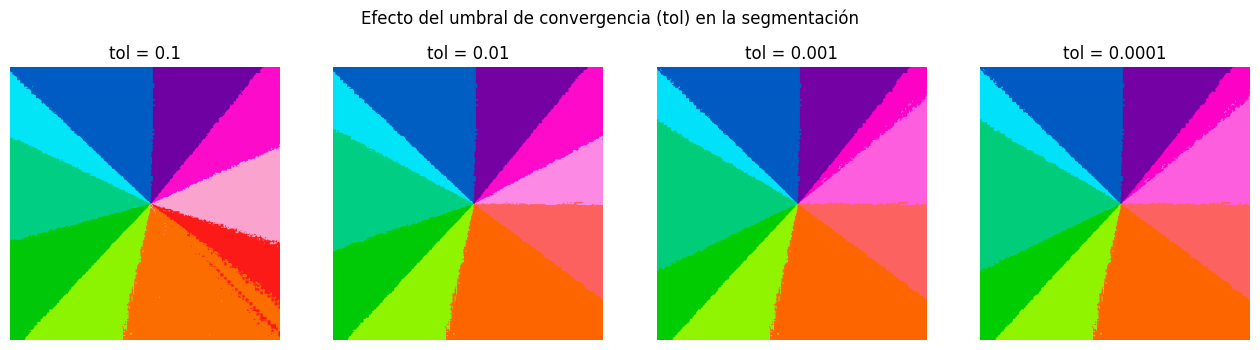

In [35]:
tol_list = [1e-1, 1e-2, 1e-3, 1e-4]
fig, axes = plt.subplots(1, len(tol_list), figsize=(16,4))
for i, tol_val in enumerate(tol_list):
    labels_tol, seg_tol = segmentar_imagen(img_2d, best_n_clusters, 
                                           cov_type='full', 
                                           max_iter=100, tol=tol_val)
    seg_tol_2d = seg_tol.reshape(rows, cols, ch)
    axes[i].imshow(seg_tol_2d)
    axes[i].set_title(f'tol = {tol_val}')
    axes[i].axis('off')

plt.suptitle("Efecto del umbral de convergencia (tol) en la segmentación")
plt.show()

### 7.3 Efecto de la forma de la matriz de covarianza

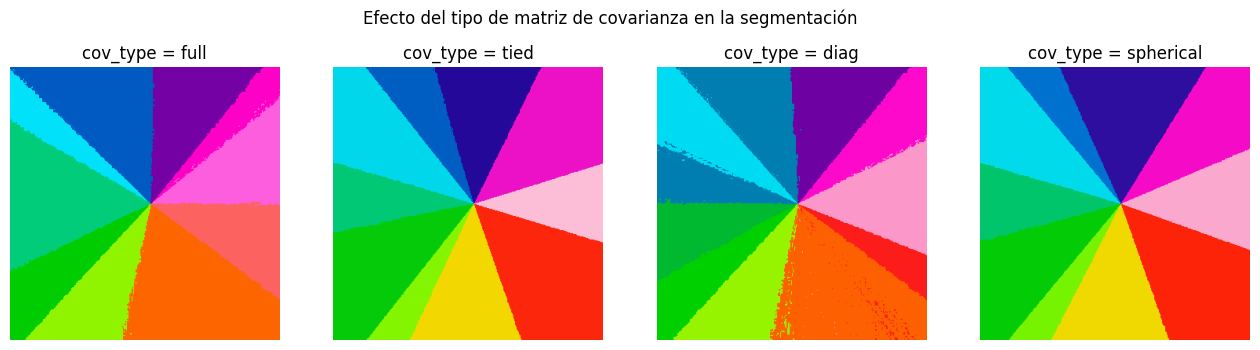

In [36]:
cov_types = ['full', 'tied', 'diag', 'spherical']
fig, axes = plt.subplots(1, len(cov_types), figsize=(16,4))
for i, ctype in enumerate(cov_types):
    labels_cov, seg_cov = segmentar_imagen(img_2d, best_n_clusters, 
                                           cov_type=ctype,
                                           max_iter=100, tol=1e-3)
    seg_cov_2d = seg_cov.reshape(rows, cols, ch)
    axes[i].imshow(seg_cov_2d)
    axes[i].set_title(f'cov_type = {ctype}')
    axes[i].axis('off')

plt.suptitle("Efecto del tipo de matriz de covarianza en la segmentación")
plt.show()

---
## Conclusiones de los resultados

### 1. Efecto del número de iteraciones (`max_iter`)

- **max_iter = 20:**  
  Se observan áreas con transiciones de color menos definidas y ciertas regiones donde la clasificación parece menos estable. El algoritmo no ha convergido lo suficiente y se aprecian bordes más irregulares.

- **max_iter = 50:**  
  La segmentación mejora respecto a las 20 iteraciones. Los bordes entre regiones se hacen un poco más precisos.

- **max_iter = 100:**  
  La convergencia del algoritmo es más estable, resultando en una segmentación más limpia y bordes más nítidos.

- **max_iter = 200:**  
  Muy similar a 100 iteraciones, lo cual sugiere que más iteraciones no siempre se traducen en grandes mejoras si el algoritmo ya ha convergido.

> **Conclusión**: Aumentar `max_iter` permite al algoritmo EM refinar mejor la solución y mejorar la segmentación, pero llega un punto donde incrementarlo más no aporta mejoras significativas.

---

### 2. Efecto del umbral de convergencia (`tol`)

- **tol = 0.1:**  
  El algoritmo se detiene rápidamente, lo cual puede dar lugar a una segmentación con bordes algo irregulares o regiones no tan bien definidas.

- **tol = 0.01:**  
  Se ve una mejoría respecto a `tol = 0.1`. El GMM afina más los parámetros de cada clúster.

- **tol = 0.001:**  
  Los límites entre las regiones de color son todavía más homogéneos. Aumenta la calidad de la segmentación.

- **tol = 0.0001:**  
  El algoritmo busca mayor precisión en la convergencia; la segmentación es similar a `tol = 0.001`, pero con ligeros refinamientos. Puede incrementar el tiempo de cómputo sin ofrecer una diferencia visual muy grande.

> **Conclusión**: Un `tol` más pequeño mejora la segmentación, ya que el algoritmo refina más los parámetros. Sin embargo, si `tol` es demasiado estricto, el tiempo de cómputo puede crecer y la mejora visual puede no justificarlo.

---

### 3. Efecto del tipo de matriz de covarianza (`cov_type`)

- **cov_type = full:**  
  Se ajusta una matriz de covarianza completa para cada clúster. Es la más flexible, pero también la más costosa. El resultado tiende a capturar mejor las correlaciones entre componentes de color.

- **cov_type = tied:**  
  Se asume que todos los clústeres comparten la misma matriz de covarianza. Esto reduce la flexibilidad pero también puede mejorar la estabilidad y rapidez del ajuste.

- **cov_type = diag:**  
  Sólo se estiman los valores diagonales de la matriz, asumiendo independencia entre canales (R, G, B). Produce segmentaciones a veces menos precisas en los bordes, pero puede ser computacionalmente más eficiente.

- **cov_type = spherical:**  
  Asume varianza isotrópica para cada clúster (un único valor por clúster). Es la más restrictiva y simple. Puede mostrar regiones más “planas” y algo menos ajustadas.

> **Conclusión**: A medida que se reduce la flexibilidad de la matriz de covarianza (de `full` hacia `spherical`), se simplifica la estimación a costa de una posible pérdida de detalle en la segmentación. La elección depende del balance entre exactitud y eficiencia computacional.

---

### Conclusión General

- **Número de Iteraciones (`max_iter`)**: Asegurarse de que sea lo suficientemente alto como para permitir la convergencia del algoritmo, pero sin exceder innecesariamente el tiempo de cómputo cuando ya se ha alcanzado un resultado estable.  
- **Umbral de Convergencia (`tol`)**: Si es muy grande, la convergencia puede ser prematura y la segmentación de menor calidad. Con valores muy pequeños, se logra mayor precisión al coste de más tiempo de cómputo.  
- **Tipo de Matriz de Covarianza (`cov_type`)**:  
  - `full` ofrece más flexibilidad pero aumenta la complejidad.  
  - `diag` y `spherical` simplifican el cómputo, aunque pueden deteriorar algo la calidad de la segmentación si las suposiciones de independencia no se cumplen.  
  - `tied` ofrece un compromiso entre flexibilidad y tiempo de cómputo.

En conjunto, las mejores configuraciones dependen de las necesidades de exactitud, el tiempo disponible para entrenar el modelo y las características de la imagen a segmentar.
